# Hyperparameter Tuning

This notebook optimizes the Random Forest model using RandomizedSearchCV.

Objectives:

- Improve ROC-AUC
- Improve Recall
- Reduce overfitting
- Identify the best hyperparameters

In [1]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

%matplotlib inline

# Load Data

In [2]:
df = pd.read_csv(
    "../data/bankruptcy_processed.csv"
)

print(df.shape)

df.head()

(43405, 26)


,A27,A24,A42,A41,A26,A22,A13,A16,A46,A15,...,A12,A25,A18,A38,A11,A14,A7,A1,A51,Bankrupt
0,1.45820,0.47706,0.128040,0.051402,0.60411,0.21402,0.166600,0.73378,1.52250,497.42,...,0.65980,0.50494,0.249760,0.50591,0.249760,0.249760,0.249760,0.200550,0.37854,0.0
1,88.44400,0.15510,0.145950,0.064371,0.43992,0.24806,0.158350,0.53838,1.12520,677.96,...,0.51680,0.39542,0.258340,0.49788,0.261140,0.258340,0.258340,0.209120,0.49988,0.0
2,86.01100,0.15510,0.231170,0.074020,0.37282,0.30260,0.244350,0.45961,1.01010,794.16,...,0.64184,0.28932,0.309060,0.51537,0.312580,0.309060,0.309060,0.248660,0.48152,0.0
3,0.94076,0.17193,0.088995,0.069622,0.36152,0.11550,0.094257,0.39803,1.56960,917.01,...,0.30163,0.57353,0.092704,0.57353,0.092704,0.092704,0.092704,0.081483,0.30734,0.0
4,1.41380,0.18732,0.122310,0.096680,0.32211,0.19832,0.121820,0.32211,0.95787,1133.20,...,0.33147,0.38677,0.187320,0.43489,0.187320,0.187320,0.187320,0.187320,0.56511,0.0


# Train Test Split

In [3]:
X = df.drop(
    columns=["Bankrupt"]
)

y = df["Bankrupt"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Baseline Model

In [5]:
baseline_rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

baseline_rf.fit(
    X_train,
    y_train
)

baseline_probs = baseline_rf.predict_proba(
    X_test
)[:, 1]

baseline_auc = roc_auc_score(
    y_test,
    baseline_probs
)

print(
    f"Baseline ROC-AUC: {baseline_auc:.4f}"
)

Baseline ROC-AUC: 0.8990


# Hyperparameter Space

In [6]:
param_dist = {

    "n_estimators":
        [200, 300, 400, 500],

    "max_depth":
        [None, 10, 20, 30, 40],

    "min_samples_split":
        [2, 5, 10, 20],

    "min_samples_leaf":
        [1, 2, 4, 8],

    "max_features":
        ["sqrt", "log2"],

    "class_weight":
        [None, "balanced"]
}

# Randomized Search

In [7]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/Users/paco/Files/bankruptcy-risk-prediction/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/paco/Files/bankruptcy-risk-prediction/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/paco/Files/bankruptcy-risk-prediction/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced'], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function w

# Best Parameters

In [8]:
print(
    "Best Parameters:\n"
)

search.best_params_

Best Parameters:



{'n_estimators': 500,
 'min_samples_split': 10,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 20,
 'class_weight': 'balanced'}

In [9]:
print(
    f"Best CV ROC-AUC: {search.best_score_:.4f}"
)

Best CV ROC-AUC: 0.9106


# Evaluate Tuned Model

In [10]:
best_rf = search.best_estimator_

y_pred = best_rf.predict(
    X_test
)

y_prob = best_rf.predict_proba(
    X_test
)[:, 1]

test_auc = roc_auc_score(
    y_test,
    y_prob
)

print(
    f"Test ROC-AUC: {test_auc:.4f}"
)

Test ROC-AUC: 0.9050


# Classification Report

In [11]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Healthy",
            "Bankrupt"
        ]
    )
)

              precision    recall  f1-score   support

     Healthy       0.97      0.97      0.97      8263
    Bankrupt       0.44      0.47      0.45       418

    accuracy                           0.95      8681
   macro avg       0.71      0.72      0.71      8681
weighted avg       0.95      0.95      0.95      8681



# Confusion Matrix

In [12]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Healthy",
        "Actual Bankrupt"
    ],
    columns=[
        "Predicted Healthy",
        "Predicted Bankrupt"
    ]
)

cm_df

,Predicted Healthy,Predicted Bankrupt
Actual Healthy,8013,250
Actual Bankrupt,223,195


# Detailed Breakdown

In [13]:
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

True Negatives : 8013
False Positives: 250
False Negatives: 223
True Positives : 195


# ROC Curve

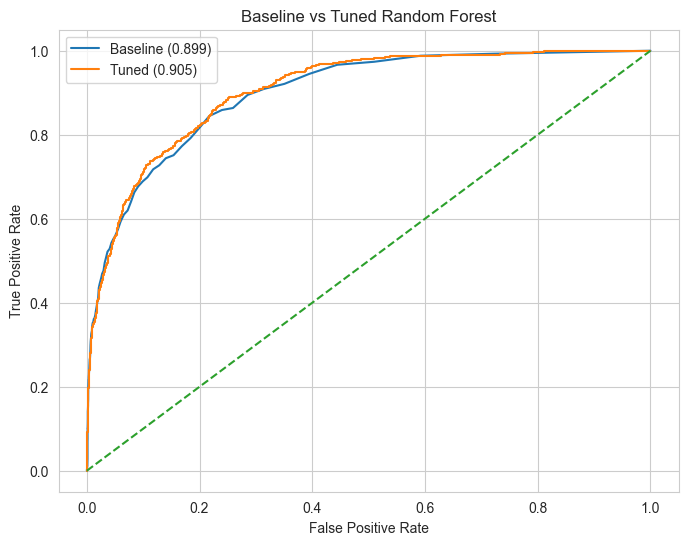

In [14]:
baseline_fpr, baseline_tpr, _ = roc_curve(
    y_test,
    baseline_probs
)

tuned_fpr, tuned_tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    baseline_fpr,
    baseline_tpr,
    label=f"Baseline ({baseline_auc:.3f})"
)

plt.plot(
    tuned_fpr,
    tuned_tpr,
    label=f"Tuned ({test_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline vs Tuned Random Forest")

plt.legend()

plt.show()

# Feature Importance

In [15]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
0,A27,0.140933
1,A24,0.093404
8,A46,0.060975
4,A26,0.058562
14,A6,0.049332
6,A13,0.047885
7,A16,0.046787
13,A35,0.039467
11,A39,0.039350
17,A25,0.038262


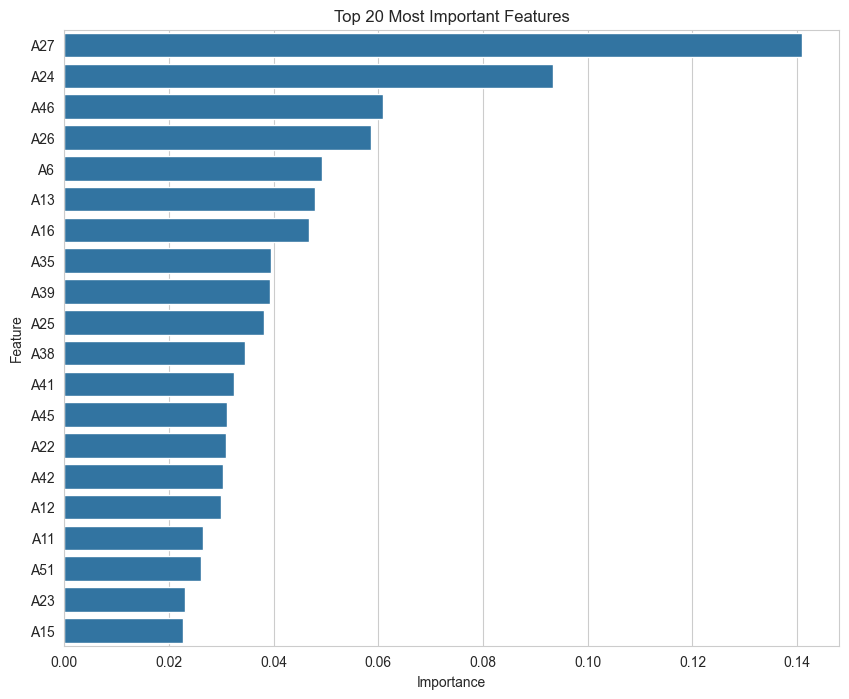

In [16]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=importance_df.head(20),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 20 Most Important Features"
)

plt.show()

# Save Best Model

In [17]:
import joblib

joblib.dump(
    best_rf,
    "../models/random_forest_tuned.pkl"
)

print("Model saved.")

Model saved.


# Final Comparison Table

In [18]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline RF",
        "Tuned RF"
    ],
    "ROC-AUC": [
        baseline_auc,
        test_auc
    ]
})

comparison

,Model,ROC-AUC
0,Baseline RF,0.898986
1,Tuned RF,0.905036
